In [34]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

In [35]:
# Read all the words
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [36]:
len(words)

32033

In [37]:
#Build Vocabulary and mappings strings/integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [38]:
# Build dataset
block_size = 3 # Context length

def build_dataset(words):

    X, Y = [], [] 

    for w in words:
        context = [0]*3
        for char in w + '.':
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '===>', itos[ix])
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
        
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [39]:
Xtr.shape, Ytr.shape #Data set
#Xte.shape, Yte.shape #Data set

(torch.Size([182625, 3]), torch.Size([182625]))

In [15]:
n_embed = 10 #embedding dimention
n_hidden = 200 #number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g) 
W1 = torch.randn(block_size * n_embed, n_hidden, generator=g)* (5/3)/((n_embed*block_size)**0.5)
#b1 = torch.randn(n_hidden, generator=g)*0.01
W2 = torch.randn(n_hidden, vocab_size, generator=g)*0.01
b2 = torch.randn(vocab_size, generator=g)*0

#Batch normalization parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.zeros((1, n_hidden))
                     

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

In [16]:
(5/3)/((n_embed*block_size)**0.5)

0.3042903097250923

In [17]:
sum(p.nelement() for p in parameters) #numbers of parameters

12297

In [18]:
for p in parameters:
    p.requires_grad = True

In [19]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [20]:
batch_size = 32
max_steps = 100000

lri = []
lossi= []
stepi = []

for i in tqdm(range(max_steps)):
    
    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] #[batch_size, 3, 2]
    embcat = emb.view(emb.shape[0], -1) #Use view instead of torch.cat(torch.unbind(emb, 1),1).shape #worse in terms of meemory
    # Linear Layer
    hpreact = embcat @ W1 # + b1
    # Batch normalization
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    # Non-linearity
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 # [32, 27] 
    loss = F.cross_entropy(logits, Yb)
    #print(loss.item())
    
    #Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #lr = lrs[i]
    lr = 0.1 if i < 50000 else 0.01

    #Update 
    for p in parameters:
        p.data += -lr * p.grad
    
    #Track stat 
    #lri.append(lre[i])
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    stepi.append(i)
    
    #break
#print(loss.item())

  0%|          | 61/100000 [00:00<05:03, 329.26it/s]

      0/ 100000: 3.3199


  1%|          | 1026/100000 [00:02<06:38, 248.07it/s]

   1000/ 100000: 2.6271


  2%|▏         | 2079/100000 [00:05<04:52, 334.92it/s]

...

 98%|█████████▊| 98130/100000 [02:19<00:02, 767.71it/s]

  98000/ 100000: 2.2015


 99%|█████████▉| 99060/100000 [02:20<00:01, 716.39it/s]

  99000/ 100000: 2.1466


100%|██████████| 100000/100000 [02:21<00:00, 705.08it/s]


In [25]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)

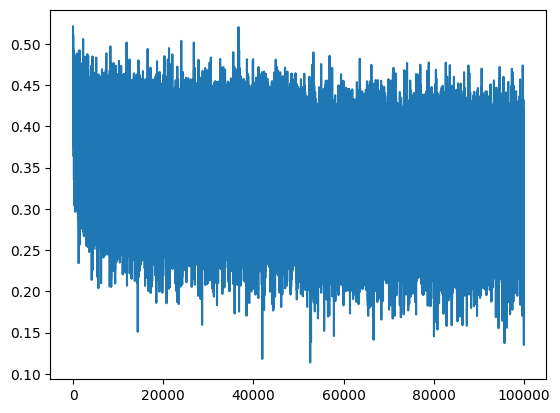

In [26]:
plt.plot(lossi)

In [28]:
@torch.no_grad()

def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
          'val' : (Xdev, Ydev),
          'test' : (Xte, Yte),}[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1
    hpreact = bngain*(hpreact - bnmean_running) / bnstd_running  + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.094926357269287
val 2.1265838146209717


In [61]:
g = torch.Generator().manual_seed(2147483647 + 10)
# Sample

for i in range(20):
    out = []
    context = [0] * 3
    while True:
        ix = 0
        emb = C[torch.tensor([context])] #[1, 3, 10]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2 
        #print(logits.shape)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]

        if ix==0:
           break 
    print(''.join(out))

mora.
kayah.
seel.
ndhoylle.
emmastendrajo.
adee.
deelin.
shi.
jenreden.
estanaraelynn.
hona.
cayshabergahimiel.
kendreelynn.
nicolan.
brence.
ryy.
juliehs.
kayshaston.
azhil.
aadyansuf.


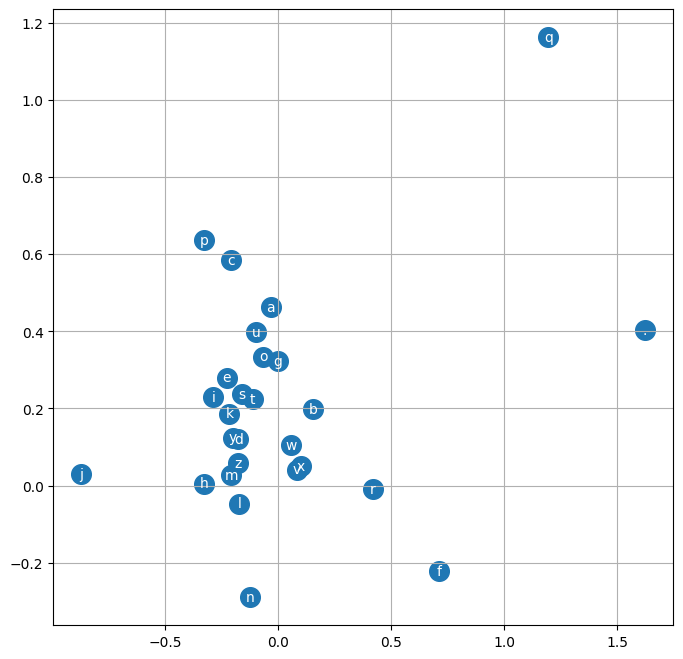

In [25]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [ ]:
# Summary 

In [54]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters trained with back-prop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # Buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # Calculate forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)# Batch mean
            xvar = x.var(0, keepdim= True)# Batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # Normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # Update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1 - self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
n_embed = 10
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g)  
layers = [
    Linear(n_embed*block_size, n_hidden),              Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]
#print(layers[2])

with torch.no_grad():
    # Last layer: make less confident
    layers[-1].gamma *= 0.1
    # All other layer: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47351


In [55]:
batch_size = 32
max_steps = 100000
lossi = []

for i in tqdm(range(max_steps)):
    
    # Mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    
    # Forward pass
    emb = C[Xb]
    out = emb.view(emb.shape[0], -1)
    for layer in layers:
            out = layer(out)
    loss = F.cross_entropy(out, Yb)
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    
    # Update 
    lr = 0.1 if i < 50000 else 0.01
    
    for p in parameters:
        p.data += -lr * p.grad
    
    #Track stat 
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    stepi.append(i)
    
    #break
#print(loss.item())

  0%|          | 29/100000 [00:00<10:52, 153.10it/s]

      0/ 100000: 3.2880


  1%|          | 1044/100000 [00:07<08:04, 204.45it/s]

   1000/ 100000: 2.2997


  2%|▏         | 2050/100000 [00:10<05:57, 274.36it/s]

...

 98%|█████████▊| 98039/100000 [06:53<00:06, 300.01it/s]

  98000/ 100000: 2.1173


 99%|█████████▉| 99042/100000 [06:57<00:03, 274.63it/s]

  99000/ 100000: 2.4315


100%|██████████| 100000/100000 [07:01<00:00, 237.21it/s]


In [56]:
@torch.no_grad()

def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
          'val' : (Xdev, Ydev),
          'test' : (Xte, Yte),}[split]
    # Forward pass
    emb = C[x]
    out = emb.view(emb.shape[0], -1)
    for layer in layers:
            out = layer(out)
    loss = F.cross_entropy(out, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0356554985046387
val 2.095242738723755


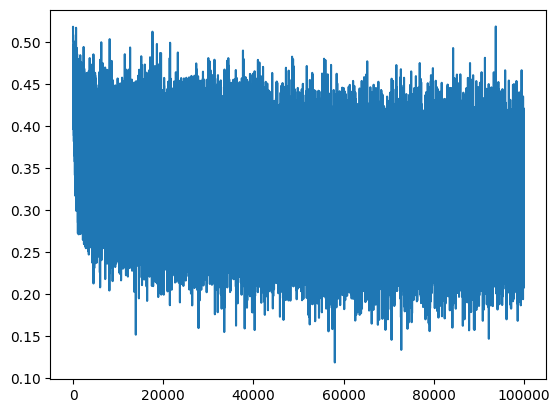

In [57]:
plt.plot(lossi)

In [ ]:
courage ! Maman ;-)